In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ------------------------------------------------------------
# CARGA DE DATOS
# ------------------------------------------------------------
data = pd.read_csv("medical_insurance.csv")
#data = pd.read_csv("/content/drive/MyDrive/Trabajo de multivariante/medical_insurance.csv")
print("Datos cargados correctamente.")
print(f"Número de filas: {data.shape[0]} | Número de columnas: {data.shape[1]}")


Datos cargados correctamente.
Número de filas: 100000 | Número de columnas: 54


In [ ]:
# --------------------------------------------------------
# 1. Selección de variables para el análisis PCA
# --------------------------------------------------------

# Las siguientes alternativas de selección de variables se mantienen comentadas
# para posibles análisis posteriores.

#vars_pca = [
     #'income', 'deductible', 'copay', 'policy_term_years',
     #'policy_changes_last_2yrs', 'annual_medical_cost',
     #'annual_premium', 'monthly_premium', 'avg_claim_amount',
     #'total_claims_paid'
 #]

# vars_pca = [
#     'visits_last_year', 'hospitalizations_last_3yrs',
#     'days_hospitalized_last_3yrs', 'medication_count',
#     'proc_imaging_count', 'proc_surgery_count',
#     'proc_physio_count', 'proc_consult_count',
#     'proc_lab_count', 'claims_count'
# ]

vars_pca = [
   'age', 'bmi', 'systolic_bp', 'diastolic_bp',
   'ldl', 'hba1c', 'risk_score', 'chronic_count'
]

X = data[vars_pca].copy()


**MODELO DE REGRESIÓN PARA LAS VARIABLES MÁS REPRESENTATIVAS DE CADA MODELO**

---



Filas usadas en la regresión (tras limpiar NaNs): 100000

==================== RESUMEN OLS ====================
                             OLS Regression Results                            
Dep. Variable:     annual_medical_cost   R-squared:                       0.095
Model:                             OLS   Adj. R-squared:                  0.095
Method:                  Least Squares   F-statistic:                     2610.
Date:                 Sat, 24 Jan 2026   Prob (F-statistic):               0.00
Time:                         17:30:20   Log-Likelihood:            -9.4173e+05
No. Observations:               100000   AIC:                         1.883e+06
Df Residuals:                    99995   BIC:                         1.884e+06
Df Model:                            4                                         
Covariance Type:             nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------

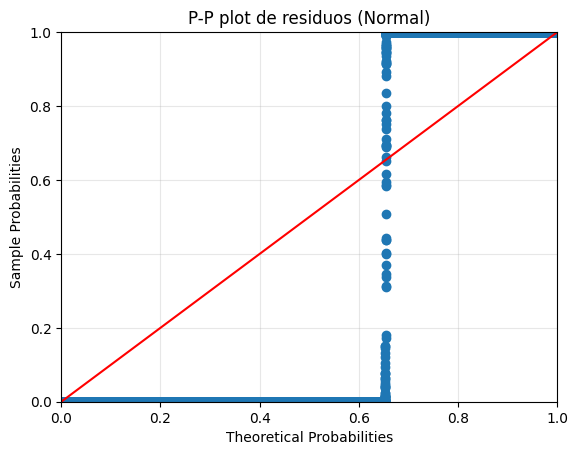

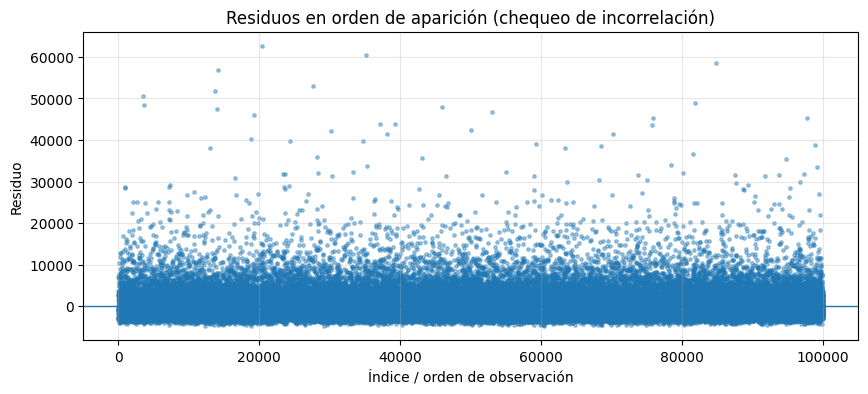


==================== REGRESIÓN AUXILIAR: residuos^2 ~ X ====================
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     261.3
Date:                Sat, 24 Jan 2026   Prob (F-statistic):          9.33e-224
Time:                        17:30:21   Log-Likelihood:            -1.9213e+06
No. Observations:              100000   AIC:                         3.843e+06
Df Residuals:                   99995   BIC:                         3.843e+06
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------

In [ ]:
# ============================================================
# REGRESIÓN: annual_medical_cost ~ risk_score + hba1c + bmi + ldl
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm
import scipy.stats

# -----------------------------
# 0) Config
# -----------------------------
y_col = "annual_medical_cost"
x_cols = ["risk_score", "hba1c", "bmi", "ldl"]

# -----------------------------
# 1) Preparar X e y (numérico + NaNs)
# -----------------------------
X_raw = data[x_cols].apply(pd.to_numeric, errors="coerce").copy()
y = pd.to_numeric(data[y_col], errors="coerce")

df_model = pd.concat([X_raw, y.rename(y_col)], axis=1).dropna()
X = df_model[x_cols]
y = df_model[y_col]

print(f"Filas usadas en la regresión (tras limpiar NaNs): {df_model.shape[0]}")

# -----------------------------
# 2) Regresión OLS
# -----------------------------
X_reg = sm.add_constant(X)  # intercepto
model = sm.OLS(y, X_reg).fit()

print("\n==================== RESUMEN OLS ====================")
print(model.summary())

print(f"\nR² = {model.rsquared:.4f}")
print(f"R² ajustado = {model.rsquared_adj:.4f}")

# -----------------------------
# 3) ANOVA GLOBAL DEL MODELO (tabla clásica)
# -----------------------------
n = int(model.nobs)          # número de observaciones
k = int(model.df_model)      # nº predictores
df_resid = int(model.df_resid)

SSR = float(model.ess)       # suma de cuadrados del modelo (explicada)
SSE = float(model.ssr)       # suma de cuadrados residual
SST = SSR + SSE              # total

MSR = SSR / k
MSE = SSE / df_resid

F_stat = MSR / MSE
p_value = float(model.f_pvalue)

anova_global = pd.DataFrame({
    "Suma de cuadrados": [SSR, SSE, SST],
    "gl": [k, df_resid, n - 1],
    "Cuadrado medio": [MSR, MSE, np.nan]
}, index=["Modelo", "Residual", "Total"])

print("\n==================== ANOVA GLOBAL DEL MODELO ====================")
print(anova_global.round(4))
print(f"\nEstadístico F = {F_stat:.4f}")
print(f"p-valor global = {p_value:.4e}")

# -----------------------------
# 4) Ecuación final del modelo
# -----------------------------
params = model.params  # incluye const
b0 = params["const"]

eq = f"{y_col} = {b0:.6f}"
for name in x_cols:
    b = params[name]
    sign = " + " if b >= 0 else " - "
    eq += f"{sign}{abs(b):.6f}·{name}"

print("\n==================== ECUACIÓN FINAL ====================")
print(eq)


# ============================================================
# 5) VALIDACIÓN DE HIPÓTESIS DEL MODELO (diagnóstico con residuos)
#    - P-P plot de residuos (normalidad aproximada)
#    - Residuos vs orden de aparición (incorrelación / independencia)
#    - Regresión auxiliar: residuos^2 ~ X (homocedasticidad)
# ============================================================

import matplotlib.pyplot as plt
from statsmodels.graphics.gofplots import ProbPlot
from statsmodels.stats.stattools import durbin_watson

# -----------------------------
# 5.1) Extraer residuos
# -----------------------------
resid = model.resid
fitted = model.fittedvalues

print("\n==================== DIAGNÓSTICO RESIDUOS ====================")
print(f"Media(residuos) = {resid.mean():.6f}")
print(f"Var(residuos)   = {resid.var(ddof=1):.6f}")

# Durbin-Watson (complemento rápido para incorrelación)
dw = durbin_watson(resid)
print(f"Durbin-Watson   = {dw:.4f}  (≈2 sugiere no autocorrelación)")

# -----------------------------
# 5.2) P-P plot de los residuos (Normal P-P)
# -----------------------------
pp = ProbPlot(resid, dist=scipy.stats.norm)
fig = pp.ppplot(line="45")
plt.title("P-P plot de residuos (Normal)")
plt.grid(True, alpha=0.3)
plt.show()


# -----------------------------
# 5.3) Residuos vs orden de aparición (orden temporal / índice)
# -----------------------------
plt.figure(figsize=(10, 4))
plt.scatter(np.arange(len(resid)),resid,s=6, alpha=0.4)
plt.axhline(0, linewidth=1)
plt.title("Residuos en orden de aparición (chequeo de incorrelación)")
plt.xlabel("Índice / orden de observación")
plt.ylabel("Residuo")
plt.grid(True, alpha=0.3)
plt.show()

# -----------------------------
# 5.4) Homocedasticidad: regresión auxiliar residuos^2 ~ X
# -----------------------------
resid2 = resid**2

X_aux = X_reg.copy()

aux_model = sm.OLS(resid2, X_aux).fit()

print("\n==================== REGRESIÓN AUXILIAR: residuos^2 ~ X ====================")
print(aux_model.summary())


**MODELO DE REGRESIÓN CON LAS CP**

---


Filas usadas en la regresión (tras limpiar NaNs): 100000

==================== RESUMEN OLS ====================
                             OLS Regression Results                            
Dep. Variable:     annual_medical_cost   R-squared:                       0.090
Model:                             OLS   Adj. R-squared:                  0.090
Method:                  Least Squares   F-statistic:                     2463.
Date:                 Sat, 24 Jan 2026   Prob (F-statistic):               0.00
Time:                         17:29:12   Log-Likelihood:            -9.4199e+05
No. Observations:               100000   AIC:                         1.884e+06
Df Residuals:                    99995   BIC:                         1.884e+06
Df Model:                            4                                         
Covariance Type:             nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------

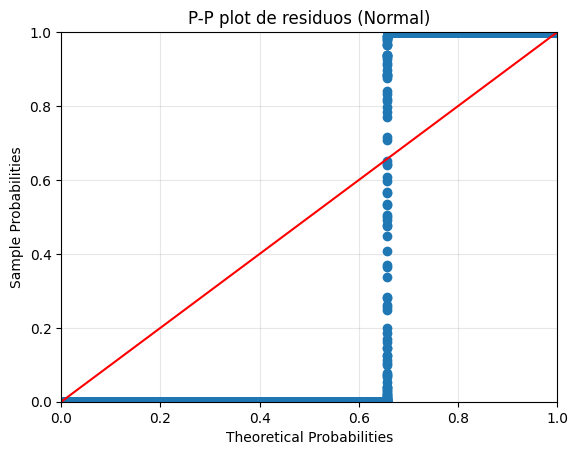

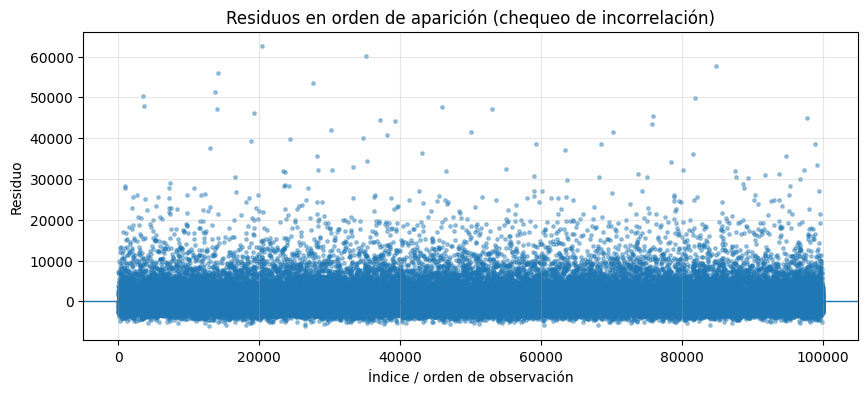


==================== REGRESIÓN AUXILIAR: residuos^2 ~ X ====================
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     281.4
Date:                Sat, 24 Jan 2026   Prob (F-statistic):          4.67e-241
Time:                        17:29:14   Log-Likelihood:            -1.9210e+06
No. Observations:              100000   AIC:                         3.842e+06
Df Residuals:                   99995   BIC:                         3.842e+06
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------

In [ ]:
# ============================================================
# REGRESIÓN: annual_medical_cost ~ CP1 + CP2 + CP3 + CP4 (PCA salud)
# ============================================================

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import statsmodels.api as sm

# -----------------------------
# 0) Config
# -----------------------------
n_components = 4
y_col = "annual_medical_cost"

# -----------------------------
# 1) Preparar X (salud) e y
# -----------------------------
X = data[vars_pca].copy()

X_num = X.apply(pd.to_numeric, errors="coerce").copy()
y = pd.to_numeric(data[y_col], errors="coerce")

df_model = pd.concat([X_num, y.rename(y_col)], axis=1).dropna()
X_num = df_model[vars_pca]
y = df_model[y_col]

print(f"Filas usadas en la regresión (tras limpiar NaNs): {df_model.shape[0]}")

# -----------------------------
# 2) Escalado + PCA (4 CP)
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

pca = PCA(n_components=n_components)
PC_scores = pca.fit_transform(X_scaled)

pc_names = [f"CP{i+1}" for i in range(n_components)]
PC_df = pd.DataFrame(PC_scores, columns=pc_names, index=df_model.index)

# -----------------------------
# 3) Regresión OLS
# -----------------------------
X_reg = sm.add_constant(PC_df)  # intercepto
model = sm.OLS(y, X_reg).fit()

print("\n==================== RESUMEN OLS ====================")
print(model.summary())

print(f"\nR² = {model.rsquared:.4f}")
print(f"R² ajustado = {model.rsquared_adj:.4f}")

# -----------------------------
# 4) ANOVA GLOBAL DEL MODELO (tabla clásica)
# -----------------------------
n = int(model.nobs)          # número de observaciones
k = int(model.df_model)      # nº predictores (CP1–CP4)
df_resid = int(model.df_resid)

SSR = float(model.ess)       # suma de cuadrados del modelo (explicada)
SSE = float(model.ssr)       # suma de cuadrados residual
SST = SSR + SSE              # total

MSR = SSR / k
MSE = SSE / df_resid

F_stat = MSR / MSE
p_value = float(model.f_pvalue)

anova_global = pd.DataFrame({
    "Suma de cuadrados": [SSR, SSE, SST],
    "gl": [k, df_resid, n - 1],
    "Cuadrado medio": [MSR, MSE, np.nan]
}, index=["Modelo", "Residual", "Total"])

print("\n==================== ANOVA GLOBAL DEL MODELO ====================")
print(anova_global.round(4))
print(f"\nEstadístico F = {F_stat:.4f}")
print(f"p-valor global = {p_value:.4e}")

# -----------------------------
# 5) Ecuación final del modelo
# -----------------------------
params = model.params  # incluye const
b0 = params["const"]
betas = [params[name] for name in pc_names]

eq = f"Coste_anual = {b0:.6f}"
for name, b in zip(pc_names, betas):
    sign = " + " if b >= 0 else " - "
    eq += f"{sign}{abs(b):.6f}·{name}"

print("\n==================== ECUACIÓN FINAL ====================")
print(eq)

# ============================================================
# 6) VALIDACIÓN DE HIPÓTESIS DEL MODELO (diagnóstico con residuos)
#    - P-P plot de residuos (normalidad aproximada)
#    - Residuos vs orden de aparición (incorrelación / independencia)
#    - Regresión auxiliar: residuos^2 ~ X (homocedasticidad)
# ============================================================

import matplotlib.pyplot as plt
from statsmodels.graphics.gofplots import ProbPlot
from statsmodels.stats.stattools import durbin_watson

# -----------------------------
# 6.1) Extraer residuos
# -----------------------------
resid = model.resid
fitted = model.fittedvalues

print("\n==================== DIAGNÓSTICO RESIDUOS ====================")
print(f"Media(residuos) = {resid.mean():.6f}")
print(f"Var(residuos)   = {resid.var(ddof=1):.6f}")

# Durbin-Watson (complemento rápido para incorrelación)
dw = durbin_watson(resid)
print(f"Durbin-Watson   = {dw:.4f}  (≈2 sugiere no autocorrelación)")

# -----------------------------
# 6.2) P-P plot de los residuos (Normal P-P)
# -----------------------------
pp = ProbPlot(resid, dist=scipy.stats.norm)
fig = pp.ppplot(line="45")
plt.title("P-P plot de residuos (Normal)")
plt.grid(True, alpha=0.3)
plt.show()


# -----------------------------
# 6.3) Residuos vs orden de aparición (orden temporal / índice)
# -----------------------------
plt.figure(figsize=(10, 4))
plt.scatter(np.arange(len(resid)),resid,s=6, alpha=0.4)
plt.axhline(0, linewidth=1)
plt.title("Residuos en orden de aparición (chequeo de incorrelación)")
plt.xlabel("Índice / orden de observación")
plt.ylabel("Residuo")
plt.grid(True, alpha=0.3)
plt.show()


# -----------------------------
# 6.4) Homocedasticidad: regresión auxiliar residuos^2 ~ X
# -----------------------------
resid2 = resid**2

X_aux = X_reg.copy()

aux_model = sm.OLS(resid2, X_aux).fit()

print("\n==================== REGRESIÓN AUXILIAR: residuos^2 ~ X ====================")
print(aux_model.summary())






**ANÁLISIS DE COMPONENTES PRINCIPALES (PCA)**

---




In [ ]:
# --------------------------------------------------------
# 1) Número de componentes a emplear
# --------------------------------------------------------
n_cp_sel = 4

# --------------------------------------------------------
# 2) Escalado estándar
# --------------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --------------------------------------------------------
# 3) PCA
# --------------------------------------------------------
pca = PCA()
pca.fit(X_scaled)

# Límite máximo de CPs
n_cp_sel = int(n_cp_sel)
n_cp_sel = max(1, min(n_cp_sel, pca.n_components_))
cp_sel_cols = [f'CP{i+1}' for i in range(n_cp_sel)]

# --------------------------------------------------------
# 4) Tabla resumen del PCA (completa)
# --------------------------------------------------------
autovalores = pca.explained_variance_
var_explicada = pca.explained_variance_ratio_ * 100
var_acumulada = var_explicada.cumsum()

tabla_pca = pd.DataFrame({
    'Componente': [f'CP{i+1}' for i in range(len(autovalores))],
    'Valor propio (λ)': autovalores.round(3),
    '% de varianza explicada': var_explicada.round(3),
    '% de varianza acumulada': var_acumulada.round(3)
})

print("\nResumen del análisis de componentes principales (PCA):\n")
print(tabla_pca.to_string(index=False))

# --------------------------------------------------------
# 5) Matriz de componentes (SPSS) = loadings (corr var–CP)
# --------------------------------------------------------
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

tabla_componentes = pd.DataFrame(
    loadings,
    columns=[f'CP{i+1}' for i in range(pca.n_components_)],
    index=vars_pca
)

# Nos quedamos SOLO con las CP seleccionadas
tabla_componentes_sel = tabla_componentes[cp_sel_cols].copy()

print(f"\nMatriz de componentes (loadings / corr var–CP) usando {n_cp_sel} CP ({', '.join(cp_sel_cols)}):")
print(tabla_componentes_sel.round(3))

# --------------------------------------------------------
# 6) Comunalidades usando SOLO las CP seleccionadas
#    h²_i = sum_j loading_ij^2
# --------------------------------------------------------
comunalidades = (tabla_componentes_sel ** 2).sum(axis=1)

tabla_comunalidades = pd.DataFrame({
    "Comunalidad (h²)": comunalidades.round(4),
    "Unicidad (1 - h²)": (1 - comunalidades).round(4)
}, index=vars_pca)

print(f"\nTabla de comunalidades usando {n_cp_sel} CP ({', '.join(cp_sel_cols)}):")
print(tabla_comunalidades.to_string())


# --------------------------------------------------------
# 7) Matriz de componentes ROTADA (Varimax) usando SOLO las CP seleccionadas
# --------------------------------------------------------
def varimax(Phi, gamma=1.0, q=50, tol=1e-6):
    """
    Rotación Varimax ortogonal.
    Phi: matriz de cargas (p x k)
    Devuelve: (cargas_rotadas, matriz_rotacion)
    """
    p, k = Phi.shape
    R = np.eye(k)
    d_old = 0.0

    for _ in range(q):
        Lambda = Phi @ R
        u, s, vh = np.linalg.svd(
            Phi.T @ (Lambda**3 - (gamma / p) * Lambda @ np.diag(np.diag(Lambda.T @ Lambda)))
        )
        R = u @ vh
        d = s.sum()
        if d_old != 0 and (d - d_old) < tol:
            break
        d_old = d

    return Phi @ R, R

# Aplicar Varimax a las cargas seleccionadas (solo CP que vas a usar)
Phi = tabla_componentes_sel.values  # (p x k)
Phi_rot, R = varimax(Phi)

tabla_componentes_rot = pd.DataFrame(
    Phi_rot,
    index=vars_pca,
    columns=cp_sel_cols
)

print(f"\nMatriz de componentes ROTADA (Varimax) usando {n_cp_sel} CP ({', '.join(cp_sel_cols)}):")
print(tabla_componentes_rot.round(3))



Resumen del análisis de componentes principales (PCA):

Componente  Valor propio (λ)  % de varianza explicada  % de varianza acumulada
       CP1             2.853                   35.658                   35.658
       CP2             1.174                   14.673                   50.332
       CP3             1.009                   12.616                   62.947
       CP4             0.994                   12.421                   75.369
       CP5             0.792                    9.902                   85.271
       CP6             0.657                    8.217                   93.487
       CP7             0.445                    5.566                   99.053
       CP8             0.076                    0.947                  100.000

Matriz de componentes (loadings / corr var–CP) usando 4 CP (CP1, CP2, CP3, CP4):
                 CP1    CP2    CP3    CP4
age            0.746 -0.340  0.033  0.050
bmi            0.057  0.082  0.978 -0.147
systolic_bp    0.769 -0.

**Gráfico de Sedimentación**

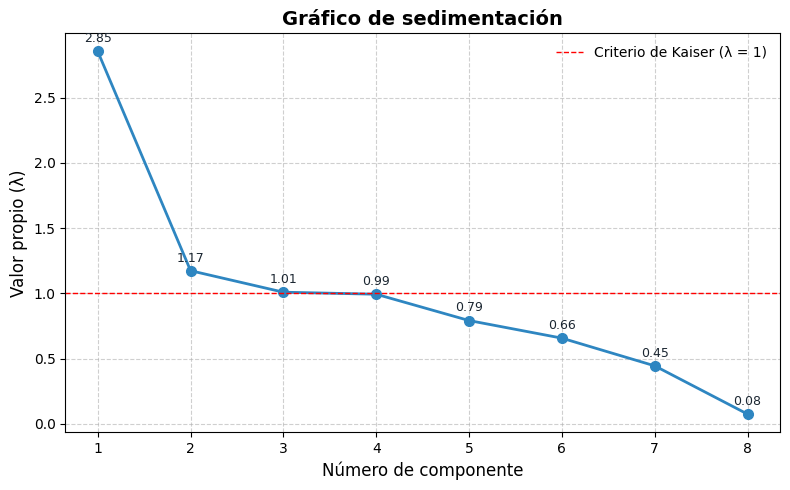

In [ ]:

plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(pca.explained_variance_) + 1),
    pca.explained_variance_,
    marker='o',
    markersize=7,
    color='#2E86C1',
    linewidth=2)

# Inclusión de etiquetas numéricas sobre cada punto
for i, val in enumerate(pca.explained_variance_):
    plt.text(i + 1, val + 0.07, f'{val:.2f}', ha='center', fontsize=9, color='#1B2631')

# Configuración estética y anotaciones del gráfico
plt.title('Gráfico de sedimentación', fontsize=14, fontweight='bold')
plt.xlabel('Número de componente', fontsize=12)
plt.ylabel('Valor propio (λ)', fontsize=12)
plt.axhline(
    y=1,
    color='red',
    linestyle='--',
    linewidth=1,
    label='Criterio de Kaiser (λ = 1)'
)
plt.legend(frameon=False, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(range(1, len(pca.explained_variance_) + 1))
plt.tight_layout()
plt.show()


**Matriz de Correlaciones**

In [ ]:
# Cálculo de la matriz de correlaciones
matriz_corr = X.corr()

# Representación gráfica de la matriz de correlaciones
plt.figure(figsize=(14, 12))
sns.heatmap(
    matriz_corr,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.4,
    cbar_kws={'label': 'Coeficiente de correlación de Pearson'}
)
plt.title('Matriz de correlaciones entre variables numéricas', fontsize=15, fontweight='bold')
plt.xticks(rotation=90, fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()


**ANÁLISIS DISCIMINANTE**


---



In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline



In [ ]:
# ------------------------------------------------------------
# 1. CONSTRUCCIÓN DE LA VARIABLE DEPENDIENTE PARA EL LDA
# ------------------------------------------------------------
# En este apartado se genera una variable categórica ('cost_group')
# a partir del coste médico anual, segmentándolo en tres niveles:
# bajo, medio y alto. Para ello se utiliza la función qcut, que
# divide la distribución en cuantiles con igual frecuencia.

# Comprobación previa: la variable debe existir y no contener nulos
if "annual_medical_cost" not in data.columns:
    raise ValueError("La columna 'annual_medical_cost' no se encuentra en el dataset.")

if data["annual_medical_cost"].isnull().any():
  raise ValueError("Hay valores nulos en 'annual_medical_cost'; revisa antes de construir la variable objetivo.")

# Creación de la variable categórica objetivo
data["cost_group"] = pd.qcut(
    data["annual_medical_cost"],
    q=3,
    labels=["Low", "Medium", "High"]
)

print("Variable dependiente 'cost_group' creada correctamente.")
print(f"Número de filas: {data.shape[0]} | Número de columnas: {data.shape[1]}")

# ------------------------------------------------------------
# 2. REVISIÓN DE LA DISTRIBUCIÓN DE LOS GRUPOS
# ------------------------------------------------------------
print("\nDistribución de la variable 'cost_group':")
print(data["cost_group"].value_counts().sort_index())

# Representación porcentual
print("\nDistribución porcentual:")
print((data["cost_group"].value_counts(normalize=True) * 100).round(2))


In [ ]:
# ------------------------------------------------------------
# 3. SELECCIÓN DE VARIABLES PARA EL ANÁLISIS DISCRIMINANTE
# ------------------------------------------------------------
# En este apartado se definen las variables predictoras que se utilizarán
# en el Análisis Discriminante Lineal (LDA). Se incluyen tanto variables
# continuas como binarias. Todas deben encontrarse presentes en el dataset
# y estar libres de valores no numéricos para garantizar la correcta ejecución
# del modelo.

vars_lda = [
    "age", "income", "household_size", "dependents",
    "bmi", "systolic_bp", "diastolic_bp", "ldl", "hba1c",
    "chronic_count", "medication_count",
    "hypertension", "diabetes", "cardiovascular_disease", "is_high_risk",
    "visits_last_year", "hospitalizations_last_3yrs", "days_hospitalized_last_3yrs",
    "proc_imaging_count", "proc_surgery_count", "proc_consult_count",
    "proc_lab_count", "proc_physio_count",
    "deductible", "copay", "claims_count",
    "avg_claim_amount", "total_claims_paid", "annual_premium"
]

# ------------------------------------------------------------
# 4. COMPROBACIÓN DE VARIABLES PARA EL LDA
# ------------------------------------------------------------

# Comprobación de que todas las variables existen en el DataFrame
vars_no_encontradas = [v for v in vars_lda if v not in data.columns]
if len(vars_no_encontradas) > 0:
    raise ValueError(
        f"Las siguientes variables seleccionadas no están presentes en el dataset:\n{vars_no_encontradas}"
    )

# Creación de la matriz predictora X
X = data[vars_lda].copy()

# Variable dependiente (y)
y = data["cost_group"]

print("Variables predictoras seleccionadas correctamente para el LDA.\n")
print("Listado de variables incluidas:")
for v in vars_lda:
    print(f" - {v}")

print(f"\nTotal de variables incluidas: {len(vars_lda)}")


In [ ]:
# ------------------------------------------------------------
# 5. ESCALADO DE LAS VARIABLES PREDICTORAS
# ------------------------------------------------------------
# El análisis discriminante lineal (LDA) es sensible a la escala de las
# variables, especialmente cuando estas presentan magnitudes muy
# diferentes. Por ello, se aplica una estandarización (media = 0,
# desviación típica = 1) mediante StandardScaler antes de ajustar el modelo.

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
print("Escalado de variables completado correctamente.")

# Comprobación básica tras el escalado
assert not np.isnan(X_scaled).any(), "Hay valores NaN tras el escalado de variables"


# ------------------------------------------------------------
# 6. AJUSTE DEL MODELO COMPLETO DE ANÁLISIS DISCRIMINANTE
# ------------------------------------------------------------
# En este apartado se ajusta el modelo LDA utilizando la versión completa
# del conjunto de variables predictoras, sin aplicar selección previa
# de variables.

lda = LinearDiscriminantAnalysis()

lda.fit(X_scaled, y)
print("Modelo discriminante LDA (completo) estimado correctamente.")


In [ ]:
# ------------------------------------------------------------
# 7. CÁLCULO DE LAS PUNTUACIONES DISCRIMINANTES
# ------------------------------------------------------------
# Una vez ajustado el modelo LDA, se proyectan las observaciones originales
# en el espacio discriminante definido por las funciones LD1, LD2, etc.
# Estas nuevas coordenadas maximizan la separación entre los niveles de la
# variable dependiente ('cost_group').

# Comprobación: el modelo debe estar ajustado
if not hasattr(lda, "means_"):
    raise RuntimeError("El modelo LDA no está ajustado. Ejecuta antes la sección de ajuste del LDA.")

# Transformación: obtención de las funciones discriminantes
X_lda = lda.transform(X_scaled)

# Conversión a DataFrame para una visualización más clara
num_componentes = X_lda.shape[1]
columnas_ld = [f"LD{i+1}" for i in range(num_componentes)]

puntuaciones_df = pd.DataFrame(X_lda, columns=columnas_ld)

print("Puntuaciones discriminantes calculadas correctamente.\n")
print("Primeras filas de las puntuaciones discriminantes:")
display(puntuaciones_df.head())


In [ ]:
# ------------------------------------------------------------
# 8. MATRIZ DE CLASIFICACIÓN
# ------------------------------------------------------------
# En este apartado se evalúa el rendimiento del modelo discriminante
# comparando la clasificación predicha frente a la clasificación real.

# Comprobación: el modelo debe estar ajustado
if not hasattr(lda, "means_"):
    raise RuntimeError("El modelo LDA no está ajustado. Ejecuta antes el apartado de ajuste del LDA.")

# Predicciones del modelo
y_pred = lda.predict(X_scaled)

# Asegurar el orden correcto de las clases (Low, Medium, High)
orden_clases = ["Low", "Medium", "High"]

# Comprobamos que no haya clases inesperadas
clases_encontradas = sorted(y.unique())
if set(clases_encontradas) != set(orden_clases):
    raise ValueError(
        f"Las clases en y no coinciden con las esperadas {orden_clases}. "
        f"Encontrado: {clases_encontradas}"
    )

matriz_clasificacion = pd.DataFrame(
    confusion_matrix(y, y_pred, labels=orden_clases),
    index=[f"{c}_real" for c in orden_clases],
    columns=[f"{c}_pred" for c in orden_clases]
)

print("Matriz de clasificación (casos originales):")
display(matriz_clasificacion)

# ------------------------------------------------------------
# 8.1 PORCENTAJE GLOBAL DE ACIERTOS (ACCURACY)
# ------------------------------------------------------------
precision_global = (y_pred == y).mean()
print(f"Porcentaje global de casos correctamente clasificados: {precision_global*100:.2f}%")

# ------------------------------------------------------------
# 8.2 METRICS REPORT
# ------------------------------------------------------------
print("\nInforme de métricas por clase:")
print(classification_report(y, y_pred, digits=4))


In [ ]:
# ------------------------------------------------------------
# 9. CENTROIDES DISCRIMINANTES
# ------------------------------------------------------------
# Los centroides discriminantes representan las medias de las puntuaciones
# en cada función discriminante (LD1, LD2, ...) para cada uno de los grupos.
# Estos puntos permiten analizar la posición relativa de los grupos en el
# espacio discriminante generado por el LDA.

# Comprobación: deben existir las puntuaciones discriminantes
if 'X_lda' not in locals():
    raise RuntimeError("No se han calculado las puntuaciones discriminantes. Ejecuta el apartado anterior.")

num_ld = X_lda.shape[1]

# Creación dinámica de etiquetas LD1, LD2, ..., LDk
ld_columns = [f"LD{i+1}" for i in range(num_ld)]

# Construcción del DataFrame con las puntuaciones y la variable de grupo
df_lda = pd.DataFrame(X_lda, columns=ld_columns)
df_lda["cost_group"] = y.values

# Cálculo de centroides discriminantes por grupo
centroides = df_lda.groupby("cost_group").mean()

print("Centroides discriminantes (medias de LD por grupo):")
display(centroides.round(4))


In [ ]:
# ------------------------------------------------------------
# 10. COEFICIENTES DE LAS FUNCIONES DISCRIMINANTES
# ------------------------------------------------------------
# Los coeficientes discriminantes (scalings) representan la contribución
# de cada variable (en la escala estandarizada) a cada una de las funciones
# discriminantes (LD1, LD2, ...).

# Comprobación: el modelo debe estar ajustado y tener scalings
if not hasattr(lda, "scalings_"):
    raise RuntimeError("El modelo LDA no está ajustado o no dispone de 'scalings_'.")

# Número de funciones discriminantes generadas
num_ld = lda.scalings_.shape[1]

# Construcción dinámica de nombres LD1, LD2, ..., LDk
ld_columns = [f"LD{i+1}" for i in range(num_ld)]

# Matriz de coeficientes (scalings)
coeficientes = pd.DataFrame(
    lda.scalings_,
    index=vars_lda,
    columns=ld_columns
)

print("Coeficientes estandarizados de las funciones discriminantes:")
display(coeficientes.round(4))


In [ ]:
# ------------------------------------------------------------
# 11. MATRIZ DE ESTRUCTURA
# ------------------------------------------------------------
# La matriz de estructura recoge la correlación entre cada variable
# predictora y las funciones discriminantes obtenidas por el modelo LDA.
#
# Interpretación:
#  - Valores altos en una LD indican que la variable contribuye
#    significativamente a la separación entre los grupos en esa dimensión.
#  - La matriz de estructura suele ser más estable y más interpretable
#    que los coeficientes estandarizados, especialmente en presencia
#    de multicolinealidad.

# Comprobación: deben existir las puntuaciones discriminantes
if "X_lda" not in locals():
    raise RuntimeError("No se han calculado las puntuaciones discriminantes. Ejecuta el apartado anterior.")

num_ld = X_lda.shape[1]  # número de funciones discriminantes

# DataFrame para almacenar las correlaciones variable – LD
estructura_df = pd.DataFrame(
    index=vars_lda,
    columns=[f"LD{i+1}" for i in range(num_ld)],
    dtype=float
)

# Cálculo de correlaciones variable – función discriminante
for var in vars_lda:
    for i in range(num_ld):
        estructura_df.loc[var, f"LD{i+1}"] = np.corrcoef(
            data[var],
            X_lda[:, i]
        )[0, 1]

# Ordenación según la carga absoluta en la primera función discriminante
estructura_df_sorted = estructura_df.reindex(
    estructura_df["LD1"].abs().sort_values(ascending=False).index
)

print("Matriz de estructura (correlaciones variables – funciones discriminantes):")
display(estructura_df_sorted.round(4))


In [ ]:
# ------------------------------------------------------------
# 12. AUTOVALORES Y VARIANZA EXPLICADA
# ------------------------------------------------------------
# En LDA, los autovalores representan la relación entre la varianza
# explicada por cada función discriminante y la varianza residual.

# Comprobación: explained_variance_ratio_ debe estar disponible tras el ajuste
if not hasattr(lda, "explained_variance_ratio_"):
    raise RuntimeError("No se puede acceder a 'explained_variance_ratio_' del LDA (depende del solver/versión).")

# Proporción de varianza explicada por cada función discriminante
var_exp = lda.explained_variance_ratio_

# Correlaciones canónicas (sqrt de la proporción de varianza explicada)
cor_can = np.sqrt(var_exp)

# Autovalores:
#   eigenvalue = corr^2 / (1 - corr^2)
autovalores = var_exp / (1 - var_exp)

tabla_autovalores = pd.DataFrame({
    "Autovalor": autovalores,
    "Correlación canónica": cor_can,
    "% Varianza": var_exp * 100,
    "% Acumulada": np.cumsum(var_exp * 100)
})

print("Tabla de autovalores y varianza explicada:")
display(tabla_autovalores.round(5))


In [ ]:
# ------------------------------------------------------------
# 13. LAMBDA DE WILKS GLOBAL
# ------------------------------------------------------------
# La Lambda de Wilks evalúa si las medias multivariantes de los grupos
# difieren de forma significativa. Valores pequeños indican que las
# funciones discriminantes separan adecuadamente los grupos.
#
# Fórmula:
#   Λ = ∏ ( 1 / (1 + eigenvalue_i) )
# Posteriormente se utiliza una aproximación Chi-cuadrado (Bartlett)
# para contrastar la hipótesis nula de no discriminación entre grupos.

from scipy.stats import chi2

# Comprobación: deben existir los autovalores
if "autovalores" not in locals():
    raise RuntimeError("No se han calculado los autovalores. Ejecuta antes el apartado correspondiente.")

# Lambda global (producto sobre todas las funciones discriminantes)
lambda_global = np.prod(1 / (1 + autovalores))

# Parámetros del contraste
n = len(data)                     # número de observaciones
p = len(vars_lda)                 # número de variables predictoras
g = data["cost_group"].nunique()  # número de grupos

# Estadístico Chi-cuadrado (aproximación de Bartlett)
chi2_stat = - (n - 1 - (p + g) / 2) * np.log(lambda_global)

# Grados de libertad
gl = p * (g - 1)

# p-valor asociado
p_value = 1 - chi2.cdf(chi2_stat, gl)

# Resultados
print(f"Lambda de Wilks (global): {lambda_global:.6f}")
print(f"Estadístico Chi-cuadrado: {chi2_stat:.4f}")
print(f"Grados de libertad: {gl}")
print(f"p-valor: {p_value:.6e}")


In [ ]:
# ------------------------------------------------------------
# 15. REPRESENTACIÓN GRÁFICA DE LAS DOS PRIMERAS FUNCIONES DISCRIMINANTES
# ------------------------------------------------------------
# Este gráfico muestra la proyección de cada individuo en el espacio
# discriminante definido por LD1 y LD2, permitiendo visualizar el grado
# de separación entre los grupos. Se añaden los centroides calculados
# previamente para resaltar la posición central de cada grupo.

# Comprobación: deben existir al menos dos funciones discriminantes
if X_lda.shape[1] < 2:
    raise RuntimeError("El modelo no ha generado al menos dos funciones discriminantes.")

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=X_lda[:, 0],                # Coordenadas LD1
    y=X_lda[:, 1],                # Coordenadas LD2
    hue=y,                        # Grupo real
    palette="Set1",
    alpha=0.6
)

# ------------------ Añadir centroides ------------------
plt.scatter(
    centroides["LD1"],
    centroides["LD2"],
    c="black",
    s=90,
    marker="X",
    edgecolor="white",
    linewidth=1.3,
    label="Centroides"
)

# ------------------ Títulos y ejes ------------------
plt.title("Funciones discriminantes canónicas (LD1 vs LD2)", fontsize=15)
plt.xlabel("Función discriminante 1 (LD1)", fontsize=12)
plt.ylabel("Función discriminante 2 (LD2)", fontsize=12)

# ------------------ Leyenda ------------------
plt.legend(
    title="Grupo de coste",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

# ------------------ Estética ------------------
plt.grid(True, linestyle="--", alpha=0.4)
plt.axhline(0, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)
plt.axvline(0, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.show()


In [ ]:
# ------------------------------------------------------------
# 16. VALIDACIÓN CRUZADA DEL MODELO COMPLETO (29 VARIABLES)
# ------------------------------------------------------------
# La validación cruzada permite evaluar la capacidad predictiva del modelo
# en datos no utilizados durante el entrenamiento, proporcionando una
# estimación más realista del rendimiento en datos no vistos.

# Matriz completa de predictores
X_full = data[vars_lda].copy()

# Pipeline: escalado dentro de cada fold + LDA
pipeline_lda = Pipeline([
    ("scaler", StandardScaler()),
    ("lda", LinearDiscriminantAnalysis())
])

# Validación cruzada estratificada (5 folds)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_full = cross_val_score(
    pipeline_lda,
    X_full,
    y,
    cv=cv,
    scoring="accuracy"
)

print("===== VALIDACIÓN CRUZADA – MODELO COMPLETO =====")
print("Accuracy por fold:", np.round(cv_scores_full, 5))
print("Accuracy media:", cv_scores_full.mean().round(5))
print("Desviación típica:", cv_scores_full.std().round(5))


**TÉCNICA STEPWISE**

---



**Nota:** *se incluyen a lo largo del código alguna explicación para interpretar mejor el código y los resultados. No obstante, toda la explicación de los resultados se encuentra en el documento del trabajo.*

Inicialmente se estimó un modelo discriminante utilizando todas las variables numéricas disponibles (modelo completo). Aunque dicho modelo presentó un porcentaje de clasificación correcto razonable (~68%), la validación cruzada mostró que su capacidad predictiva fuera de muestra no mejoraba respecto a un modelo más reducido. Además, la inclusión de un elevado número de predictores dificulta la interpretación clínica y económica de las funciones discriminantes.

Por este motivo, y siguiendo recomendaciones metodológicas habituales en análisis multivariante, se aplicó un procedimiento de selección por pasos (stepwise) basado en la minimización sucesiva de la Lambda de Wilks. Este método permite identificar el subconjunto de variables que realmente contribuye a la discriminación entre grupos, obteniendo un modelo parsimonioso con igual o mayor capacidad clasificatoria.

El modelo final resultante incluye únicamente siete variables, todas ellas relacionadas con la prima del seguro, la carga de enfermedad crónica y el uso intensivo del sistema sanitario. Este modelo reducido ofrece un equilibrio óptimo entre capacidad predictiva, simplicidad e interpretabilidad, por lo que se adopta como modelo final del análisis discriminante.

In [ ]:
# ------------------------------------------------------------
# MATRICES E Y H (within-group & between-group)
# ------------------------------------------------------------
def EH_matrices(X_df, y):
    """Calcula E (intra-grupos) y H (entre-grupos) para LDA clásico.

    X_df: DataFrame de predictores (numéricos, sin nulos)
    y:    Series con la etiqueta de grupo (sin nulos)
    """
    # Comprobaciones básicas (para evitar errores tontos más adelante)
    if X_df.isnull().any().any():
        raise ValueError("Hay valores nulos en X_df. Revisa/imputa antes de continuar.")
    if y.isnull().any():
        raise ValueError("Hay valores nulos en y. Revisa/imputa antes de continuar.")

    grupos = np.unique(y)
    X = X_df.to_numpy()
    y_arr = y.to_numpy()

    n, p = X.shape
    mean_total = X.mean(axis=0)

    E = np.zeros((p, p))
    H = np.zeros((p, p))

    for grupo in grupos:
        Xg = X[y_arr == grupo]
        ng = Xg.shape[0]
        mean_g = Xg.mean(axis=0)

        # E: dispersión intra-grupo
        E += (Xg - mean_g).T @ (Xg - mean_g)

        # H: dispersión entre-grupos
        diff = (mean_g - mean_total).reshape(p, 1)
        H += ng * (diff @ diff.T)

    return E, H


# ------------------------------------------------------------
# LAMBDA DE WILKS
# ------------------------------------------------------------
def wilks_lambda(E, H):
    """Lambda de Wilks: det(E) / det(E + H)."""
    # Con determinantes a veces hay problemas numéricos; usamos slogdet
    sign_E, logdet_E = np.linalg.slogdet(E)
    sign_EH, logdet_EH = np.linalg.slogdet(E + H)

    # Si alguna matriz no es definida positiva / singular, devolvemos un valor “seguro”
    if sign_E <= 0 or sign_EH <= 0:
        # Suele ocurrir por colinealidad fuerte o variables redundantes
        return np.nan

    # det(E)/det(E+H) = exp(logdet(E) - logdet(E+H))
    return float(np.exp(logdet_E - logdet_EH))


# ------------------------------------------------------------
# F parcial
# ------------------------------------------------------------
def F_parcial(lambda_value, n, p, g):
    """F aproximado a partir de lambda (criterio tipo stepwise).

    F = ((1 - λ) / λ) * ((n - g - p) / p)
    """
    if lambda_value is None or np.isnan(lambda_value):
        return np.nan

    # protección básica
    if lambda_value <= 0 or lambda_value >= 1:
        return 0.0

    return ((1 - lambda_value) / lambda_value) * ((n - g - p) / p)


In [ ]:
def stepwise_adjusted(
        X_df, y,
        F_enter=10,
        delta_lambda_min=0.001,
        max_vars=30,
        verbose=True):
    """Selección stepwise de variables basada en Lambda de Wilks y un F aproximado.

    - Entra una variable si: F >= F_enter y la mejora en Lambda es >= delta_lambda_min
    - Se detiene si no entra ninguna variable o se alcanza max_vars
    """
    grupos = y.unique()
    n = len(y)
    g = len(grupos)

    variables_disponibles = list(X_df.columns)
    variables_seleccionadas = []

    lambda_prev = 1.0

    if verbose:
        print("\nInicio del procedimiento stepwise\n")

    while len(variables_seleccionadas) < max_vars:

        mejor_var = None
        mejor_lambda = None
        mejor_F = -np.inf

        # Evaluar todas las variables candidatas
        for var in variables_disponibles:

            vars_candidatas = variables_seleccionadas + [var]
            X_temp = X_df[vars_candidatas]

            E, H = EH_matrices(X_temp, y)
            lambda_new = wilks_lambda(E, H)

            # Si hay problemas numéricos (colinealidad fuerte), saltamos esta candidata
            if lambda_new is None or np.isnan(lambda_new):
                continue

            p = len(vars_candidatas)
            F_new = F_parcial(lambda_new, n=n, p=p, g=g)

            # Criterios de entrada
            mejora_lambda = (lambda_prev - lambda_new)
            if (F_new >= F_enter) and (mejora_lambda >= delta_lambda_min):
                if F_new > mejor_F:
                    mejor_var = var
                    mejor_F = F_new
                    mejor_lambda = lambda_new

        # Condición de parada
        if mejor_var is None:
            if verbose:
                print("\nNo entra ninguna variable más. Fin del stepwise.")
            break

        # Registrar variable seleccionada
        variables_seleccionadas.append(mejor_var)
        variables_disponibles.remove(mejor_var)
        lambda_prev = mejor_lambda

        if verbose:
            print(f"Entra: {mejor_var:30}  Lambda={mejor_lambda:.6f}  F={mejor_F:.2f}")

    return variables_seleccionadas


In [ ]:
# ------------------------------------------------------------
# EJECUCIÓN DEL PROCEDIMIENTO STEPWISE
# ------------------------------------------------------------

vars_stepwise = stepwise_adjusted(
    X_df=data[vars_lda],
    y=data["cost_group"],
    F_enter=10,
    delta_lambda_min=0.001,
    max_vars=30
)

print("\nVariables seleccionadas mediante stepwise (orden de entrada):")
for i, v in enumerate(vars_stepwise, start=1):
    print(f"{i}. {v}")


In [ ]:
vars_stepwise = stepwise_adjusted(
    X_df = data[vars_lda],
    y = data["cost_group"],
    F_enter = 10,
    delta_lambda_min = 0.001,
    max_vars = 30
)

print("\nVariables seleccionadas (orden de entrada):")
for i, v in enumerate(vars_stepwise, 1):
    print(f"{i}. {v}")


La decisión de incorporar o no una variable al modelo durante el procedimiento stepwise se basa en dos criterios estadísticos fundamentales: la reducción de la Lambda de Wilks (λ) y el valor de la prueba F parcial. La Lambda de Wilks es un indicador multivariante que mide la proporción de variabilidad no explicada por las funciones discriminantes. Cuanto más pequeña es λ, mayor es la separación conseguida entre los grupos. Por ello, una variable solo se incorpora al modelo si su inclusión reduce de forma apreciable la Lambda de Wilks respecto al modelo anterior (Δλ ≥ 0,001), lo que garantiza que aporta información discriminante adicional y no redundante.

El segundo criterio es la prueba F parcial, definida como el cociente entre la varianza explicada y la varianza residual tras añadir la nueva variable. Valores elevados de F indican que la variable contribuye de forma significativa a mejorar la discriminación entre grupos. En este estudio se empleó un umbral de entrada F ≥ 10, lo que permite restringir el modelo únicamente a predictores con un efecto claramente relevante, especialmente importante en muestras muy grandes donde pequeñas diferencias pueden resultar estadísticamente significativas. De este modo, la combinación de ambos criterios asegura que el modelo final sea parsimonioso, interpretable y compuesto únicamente por variables con verdadera capacidad discriminante.

In [ ]:
# ------------------------------------------------------------
# 17. AJUSTE DEL MODELO DISCRIMINANTE (STEPWISE)
# ------------------------------------------------------------
# Se estima un modelo LDA utilizando únicamente las variables
# seleccionadas mediante el procedimiento stepwise.
# El ajuste se realiza sobre las variables estandarizadas.

# Comprobación: debe existir la lista de variables seleccionadas
if "vars_stepwise" not in locals():
    raise RuntimeError("'vars_stepwise' no está definido. Ejecuta antes el apartado de stepwise.")

if len(vars_stepwise) == 0:
    raise RuntimeError("El procedimiento stepwise no seleccionó ninguna variable.")

# Matriz de predictores del modelo reducido
X_step = data[vars_stepwise].copy()

# Escalado
scaler_step = StandardScaler()
X_step_scaled = scaler_step.fit_transform(X_step)

# Ajuste del modelo LDA reducido
lda_step = LinearDiscriminantAnalysis()
lda_step.fit(X_step_scaled, y)

print("Modelo LDA (stepwise) ajustado correctamente.\n")
print(f"Variables incluidas en el modelo stepwise ({len(vars_stepwise)}):")
for v in vars_stepwise:
    print(" -", v)


In [ ]:
# ------------------------------------------------------------
# 18. MATRIZ DE CLASIFICACIÓN
# ------------------------------------------------------------

# Predicciones del modelo stepwise
y_pred_step = lda_step.predict(X_step_scaled)

# Orden correcto de clases
orden_clases = ["Low", "Medium", "High"]

# Validación de clases
clases_encontradas = sorted(y.unique())
if set(clases_encontradas) != set(orden_clases):
    raise ValueError(f"Clases inesperadas en y: {clases_encontradas}")

# Matriz de confusión formateada
matriz_stepwise = pd.DataFrame(
    confusion_matrix(y, y_pred_step, labels=orden_clases),
    index=[f"{c}_real" for c in orden_clases],
    columns=[f"{c}_pred" for c in orden_clases]
)

print("Matriz de clasificación (modelo stepwise):")
display(matriz_stepwise)

# Precisión global
precision_stepwise = (y_pred_step == y).mean()
print(f"Porcentaje correctamente clasificado (stepwise): {precision_stepwise*100:.2f}%")


La matriz de clasificación del modelo discriminante reducido (stepwise) muestra un porcentaje global de aciertos del 68,35 %, prácticamente idéntico al obtenido con el modelo completo. Este resultado indica que, pese a utilizar únicamente siete variables predictoras, el modelo stepwise mantiene la misma capacidad discriminante que el modelo inicial de 29 variables, lo que confirma su carácter parsimonioso y eficiente.

In [ ]:
# ------------------------------------------------------------
# 19. PUNTUACIONES DISCRIMINANTES (LD1, LD2) – STEPWISE
# ------------------------------------------------------------

# Comprobación: el modelo stepwise debe estar ajustado
if not hasattr(lda_step, "means_"):
    raise RuntimeError("El modelo LDA stepwise no está ajustado. Ejecuta antes el apartado de ajuste.")

# Transformación al espacio discriminante
X_step_lda = lda_step.transform(X_step_scaled)

# Número de funciones discriminantes
num_ld_step = X_step_lda.shape[1]
ld_cols_step = [f"LD{i+1}" for i in range(num_ld_step)]

# DataFrame con las puntuaciones discriminantes
puntuaciones_step_df = pd.DataFrame(X_step_lda, columns=ld_cols_step)

print("\nPrimeras filas de las puntuaciones discriminantes (stepwise):")
display(puntuaciones_step_df.head())


In [ ]:
# ------------------------------------------------------------
# 20. CENTROIDES DISCRIMINANTES (STEPWISE)
# ------------------------------------------------------------

# Construcción del DataFrame con puntuaciones y grupos
df_step = puntuaciones_step_df.copy()
df_step["cost_group"] = y.values

# Cálculo de centroides discriminantes por grupo
centroides_step = df_step.groupby("cost_group").mean()

print("\nCentroides discriminantes del modelo stepwise:")
display(centroides_step.round(4))



In [ ]:
# ------------------------------------------------------------
# 21. COEFICIENTES DE LAS FUNCIONES DISCRIMINANTES (STEPWISE)
# ------------------------------------------------------------
# Coeficientes estandarizados (scalings_) del modelo reducido.

num_ld_step = lda_step.scalings_.shape[1]
ld_cols_step = [f"LD{i+1}" for i in range(num_ld_step)]

coef_stepwise = pd.DataFrame(
    lda_step.scalings_,
    index=vars_stepwise,
    columns=ld_cols_step
)

print("Coeficientes estandarizados del modelo stepwise:")
display(coef_stepwise.round(4))


In [ ]:
# ------------------------------------------------------------
# 22. MATRIZ DE ESTRUCTURA (STEPWISE)
# ------------------------------------------------------------
# Correlación entre las variables seleccionadas y las funciones
# discriminantes obtenidas en el modelo stepwise.

# DataFrame para almacenar las correlaciones variable – LD
estructura_stepwise = pd.DataFrame(
    index=vars_stepwise,
    columns=ld_cols_step,
    dtype=float
)

# Cálculo de correlaciones
for i, var in enumerate(vars_stepwise):
    for ld in range(num_ld_step):
        estructura_stepwise.loc[var, f"LD{ld+1}"] = np.corrcoef(
            X_step_scaled[:, i],
            X_step_lda[:, ld]
        )[0, 1]

# Ordenación según la carga absoluta en LD1
estructura_stepwise_sorted = estructura_stepwise.reindex(
    estructura_stepwise["LD1"].abs().sort_values(ascending=False).index
)

print("Matriz de estructura (modelo stepwise):")
display(estructura_stepwise_sorted.round(4))


In [ ]:
# ------------------------------------------------------------
# 23. GRÁFICO DISCRIMINANTE LD1–LD2 (STEPWISE)
# ------------------------------------------------------------

# DataFrame para la representación gráfica
plot_df_step = pd.DataFrame({
    "LD1": X_step_lda[:, 0],
    "LD2": X_step_lda[:, 1],
    "Grupo": y.values
})

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=plot_df_step,
    x="LD1",
    y="LD2",
    hue="Grupo",
    palette="Set1",
    alpha=0.6
)

# Centroides del modelo stepwise
plt.scatter(
    centroides_step["LD1"],
    centroides_step["LD2"],
    c="black",
    s=90,
    marker="X",
    edgecolor="white",
    linewidth=1.3,
    label="Centroides"
)

plt.title("Funciones discriminantes canónicas (modelo stepwise)", fontsize=14)
plt.xlabel("LD1")
plt.ylabel("LD2")

plt.grid(True, linestyle="--", alpha=0.4)

plt.legend(
    title="Grupo de coste",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


In [ ]:
# ------------------------------------------------------------
# 24. VALIDACIÓN CRUZADA DEL MODELO STEPWISE
# ------------------------------------------------------------

X_step_final = data[vars_stepwise].copy()

pipeline_step = Pipeline([
    ("scaler", StandardScaler()),
    ("lda", LinearDiscriminantAnalysis())
])

cv_scores_step = cross_val_score(
    pipeline_step,
    X_step_final,
    y,
    cv=cv,
    scoring="accuracy"
)

print("\n===== VALIDACIÓN CRUZADA – MODELO STEPWISE =====")
print("Accuracy por fold:", np.round(cv_scores_step, 5))
print("Accuracy media:", cv_scores_step.mean().round(5))
print("Desviación típica:", cv_scores_step.std().round(5))


Los resultados de la validación cruzada muestran que el modelo discriminante obtenido mediante el procedimiento stepwise —basado únicamente en siete predictores— alcanza prácticamente la misma capacidad de clasificación que el modelo completo (68.37 % frente a 68.23 %). Además, la estabilidad del rendimiento entre particiones es muy elevada, con una desviación típica inferior al 0.35 %, lo que indica que el modelo no depende de una partición concreta de los datos y generaliza de forma robusta.

Este resultado confirma que la mayor parte de la información discriminante del conjunto de datos se concentra en un subconjunto reducido de variables asociadas a la prima anual del seguro, la carga de enfermedad crónica y la intensidad de uso de servicios sanitarios. La ausencia de mejoras sustanciales al incorporar el resto de predictores sugiere que estos aportan información redundante o poco relevante para la separación entre grupos de coste. En consecuencia, el modelo stepwise puede considerarse una solución parsimoniosa y eficiente, capaz de caracterizar perfiles de gasto médico con un nivel de precisión comparable al del modelo completo, pero con una estructura más interpretable y clínicamente coherente.